In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import xgboost as xgb

In [2]:
data = pd.read_csv('AB_NYC_2019.csv')

In [3]:
data.drop(columns = ['id', 'name', 'host_id',  'host_name', 'last_review', 'neighbourhood'], inplace = True)

categorical_features = ['neighbourhood_group', 'room_type']
numeric_features = [x for x in list(data.columns) if x not in categorical_features]
#numeric_features = ['latitude', 'longitude', 'price', 'minimum_nights']

data[numeric_features] = data[numeric_features].fillna(data[numeric_features].median())

data[categorical_features] = data[categorical_features].fillna(data[categorical_features].mode().iloc[0])
data = pd.get_dummies(data, columns = categorical_features, dtype=int, drop_first = True)

sc = StandardScaler()
data[numeric_features] = sc.fit_transform(data[numeric_features])

In [4]:
#Apply PCA to Airbnb dataset numeric features
pca = PCA(n_components=3)
pca_result = pca.fit_transform(data)

Optimal number of components 9


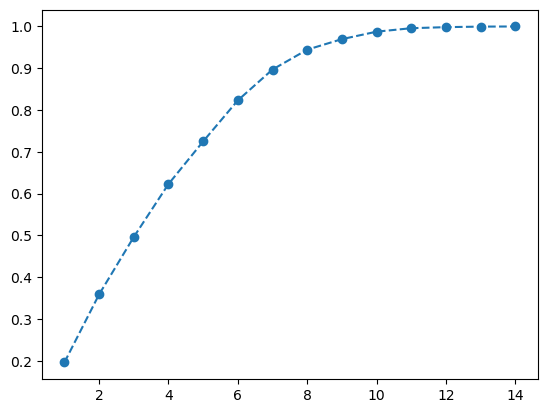

In [5]:
#Q2) Plot explained variance ratio — how many components capture 95% variance?
pca_full = PCA()
pca_full.fit(data)
explained_variance = pca_full.explained_variance_ratio_
cumsum = explained_variance.cumsum()
plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='--')
optimal_num_components = len(cumsum[cumsum <= 0.95]) + 1
print("Optimal number of components", optimal_num_components)

In [6]:
pca = PCA(n_components=9)
pca_result = pca.fit_transform(data)

In [7]:
#Q3) Apply t-SNE on Titanic — visualize survivor vs non-survivor clusters
titanic = pd.read_csv('Titanic-Dataset.csv')

y = titanic['Survived']
X = titanic.drop(columns = ['Survived'])

X.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)

categorical_features = ['Sex', 'Embarked']
numeric_features = [x for x in list(X.columns) if x not in categorical_features]
#numeric_features = ['latitude', 'longitude', 'price', 'minimum_nights']


X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())

X[categorical_features] = X[categorical_features].fillna(X[categorical_features].mode().iloc[0])
X = pd.get_dummies(X, columns = categorical_features, dtype=int)

sc = StandardScaler()
X[numeric_features] = sc.fit_transform(X[numeric_features])

def plot_TSNE(data):
    
    tsne = TSNE(n_components=2,random_state=0,n_iter_without_progress=5000,verbose=3,perplexity=30,learning_rate=200)
    embeddings = tsne.fit_transform(data)
    return embeddings

embeddings = plot_TSNE(X)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 891 samples in 0.004s...
[t-SNE] Computed neighbors for 891 samples in 0.042s...
[t-SNE] Computed conditional probabilities for sample 891 / 891
[t-SNE] Mean sigma: 0.019889
[t-SNE] Computed conditional probabilities in 0.041s
[t-SNE] Iteration 50: error = 57.2347488, gradient norm = 0.0874853 (50 iterations in 0.379s)
[t-SNE] Iteration 100: error = 53.1110573, gradient norm = 0.0690777 (50 iterations in 0.305s)
[t-SNE] Iteration 150: error = 52.0064926, gradient norm = 0.0581971 (50 iterations in 0.253s)
[t-SNE] Iteration 200: error = 51.6119652, gradient norm = 0.0619586 (50 iterations in 0.266s)
[t-SNE] Iteration 250: error = 51.4079208, gradient norm = 0.0586821 (50 iterations in 0.282s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.407921
[t-SNE] Iteration 300: error = 0.3076936, gradient norm = 0.0051607 (50 iterations in 0.251s)
[t-SNE] Iteration 350: error = 0.2509002, gradient norm = 0.0021157 (

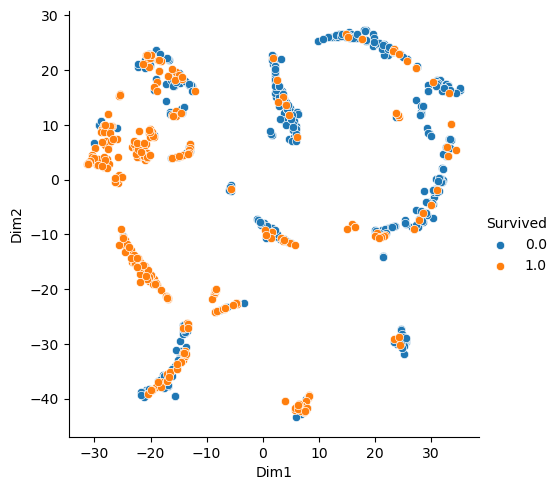

In [8]:
plot_data = np.hstack((embeddings,np.array(y).reshape(len(y),1)))
    
plot_df = pd.DataFrame(plot_data,columns=['Dim1','Dim2','Survived'])
    
sns.FacetGrid(plot_df,hue="Survived",height=5).map(sns.scatterplot,"Dim1","Dim2").add_legend()

Optimal number of components 5
[0.44072486 0.68691753 0.7958689  0.89938839 0.97448744 1.
 1.         1.        ]


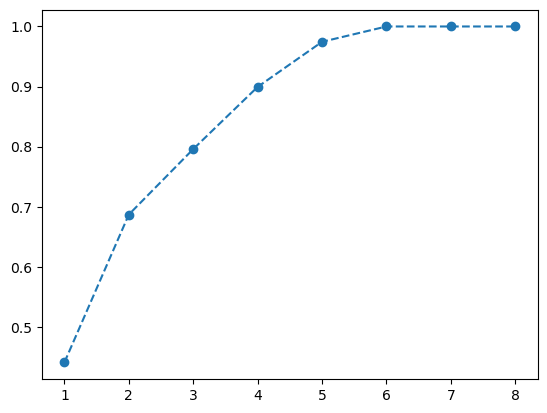

In [9]:
#Q4) Apply PCA as a preprocessing step before XGBoost — does it help or hurt performance?

pca_full = PCA()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
pca_full.fit(X_train)
explained_variance = pca_full.explained_variance_ratio_
cumsum = explained_variance.cumsum()
plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='--')
optimal_num_components = len(cumsum[cumsum <= 0.95]) + 1
print("Optimal number of components", optimal_num_components)

print(cumsum)

In [10]:
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_train)
pca_test = pca.transform(X_test)
print("Comparing dimesions", pca_test.shape, X_test.shape, y_test.shape)

#X_train, X_test, y_train, y_test = train_test_split(pca_result, y, test_size=0.15, random_state=42)

model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)

model.fit(pca_result, y_train)
test_accuracy = model.score(pca_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")

train_accuracy = model.score(pca_result, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = model.predict(pca_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Comparing dimesions (134, 5) (134, 8) (134,)
Test set accuracy: 0.8134
Train set accuracy: 0.9723
Precision score is 0.7818181818181819
Recall score is 0.7678571428571429
F1 Score is 0.7747747747747747


In [ ]:
'''
Comparison between XGBoost alone and XGBoost with PCA, is that there is not much improvement seen if PCA as used as a preprocessing step before 
pushing the data to be trained by XGBoost.
'''